# Part A: Identification of Candidate Datasets

**Spotify Recommendation**

Source: https://www.kaggle.com/datasets/bricevergnou/spotify-recommendation

Course: Clustering, anomaly detection

Beyond the Course: Content Recommendation, Dimensionality Reduction

Datasetsize and Structure: 200 song tracks with categorical attributes (energy, loudness, tempo, etc.) and a binary target variable representing like/dislike

Data Types: Nacousticness, danceability, duration_ms, energy,instrumentalness, key, liveness, loudness, mode, speechiness, tempo, duration, time signarue, liked

Target Variable: Liked

Licensing or usage constraints: Public Domain


**COVID-19 Tweet Hashtags**

Source: https://github.com/GudanDeco/Latent-influence-network/blob/main/Data_example/100_HASHTAG.csv


Course: Clustering, Frequent Itemset Mining

Beyond the Course: Latent Influence Networks,  Content Recommendation

Datasetsize and Structure: 17,469 entries representing tweets made by certain users and the hashtags found in the posts.

Data Types: user_id, target

Target Variable: Target (twitter hashtags)

Licensing or usage constraints: Public Domain


**Infectious Disease Simulation**

Source: https://osf.io/wafng/?view_only=dd51de3e6086406a8fe8c9b206c4d802


Course: Stream Mining, Frequent Itemset Mining, Clustering, Graph Mining

Beyond the Course: Health Informatics, Modeling and Simulation

Datasetsize and Structure: 9,636 entries each representing an infected agent and their movement over time

Data Types: step, agentID, regionID, timestamp, location, checkIn

Target Variable: None

Licensing or usage constraints: Public Domain


# Part B: Comparative Analysis of Datasets

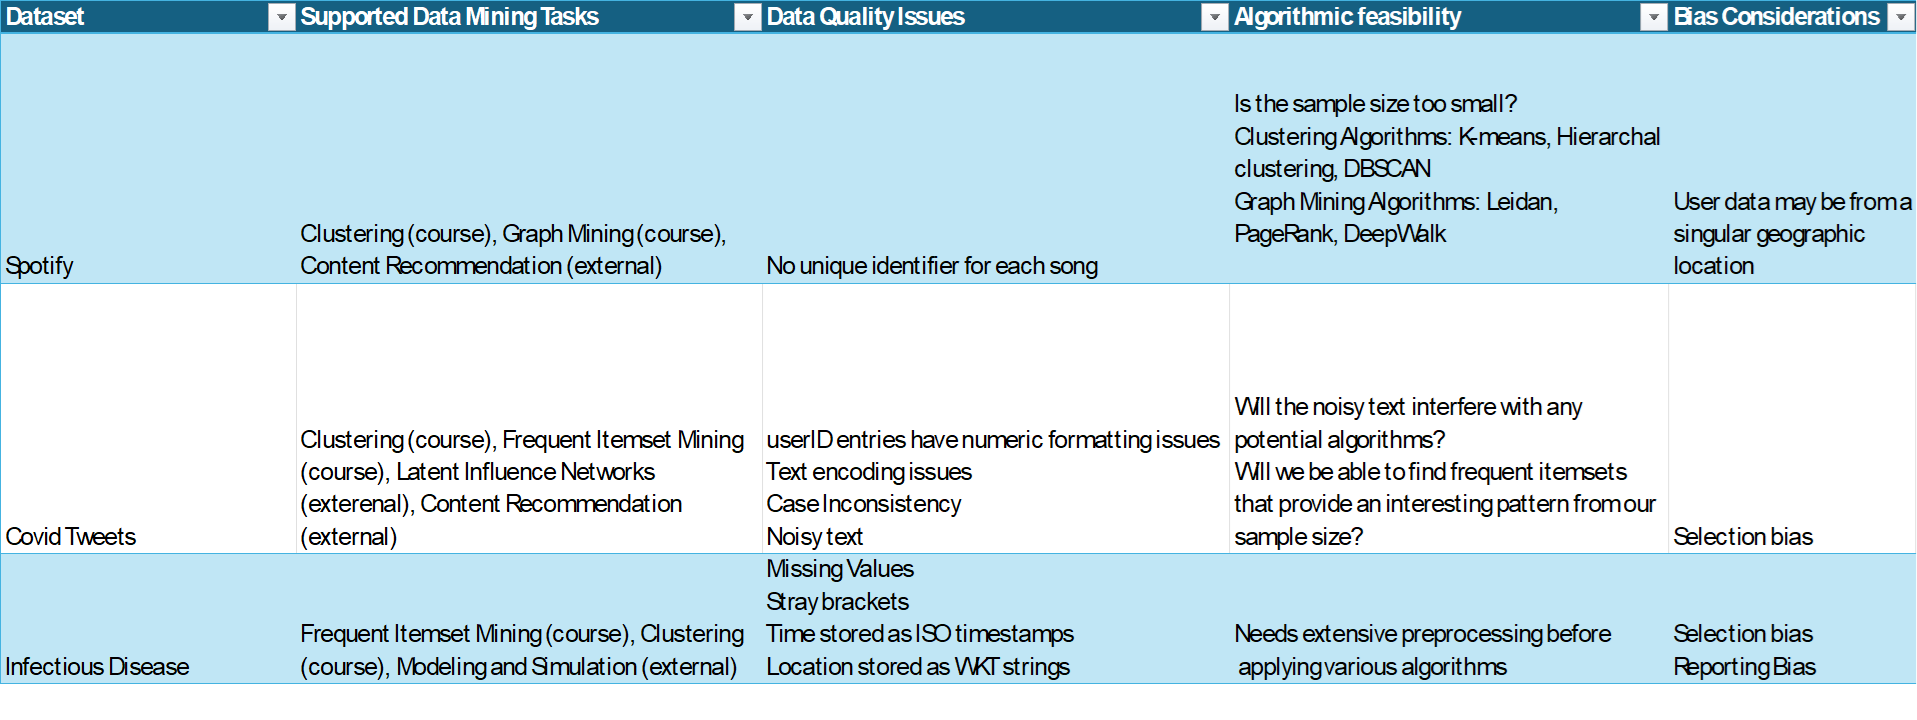

# Part C: Dataset Selection

Spotify Recommendation Data

Reasons
*   Can construct graphs used for graph mining
*   Supports frequent itemset analysis

Tradeoffs
* Smaller dataset
* No specific demographic information




# Part D: EDA

/tmp/ipython-input-1645088754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='liked', y='energy', data=df, palette='magma')


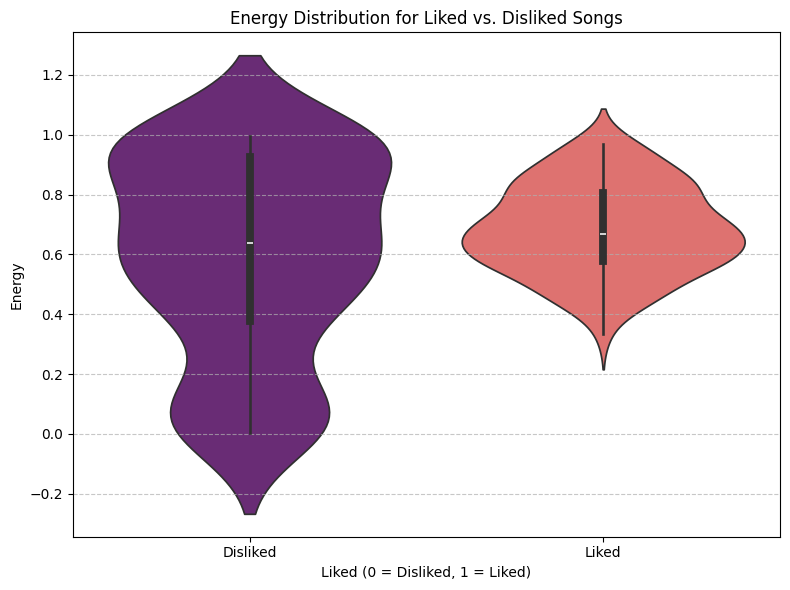

Violin plot comparing energy for liked vs. disliked songs displayed.


In [15]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='liked', y='energy', data=df, palette='magma')
plt.title('Energy Distribution for Liked vs. Disliked Songs')
plt.xlabel('Liked (0 = Disliked, 1 = Liked)')
plt.ylabel('Energy')
plt.xticks([0, 1], ['Disliked', 'Liked'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Violin plot comparing energy for liked vs. disliked songs displayed.")

Disliked songs span a larger energy level. Liked songs have an energy level range from 0.2 - 1.1. Median is around 0.7 This indicates that have a preference to moderate-high energy level songs.

/tmp/ipython-input-4270756098.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["duration_range", "liked"])


<Figure size 1000x600 with 0 Axes>

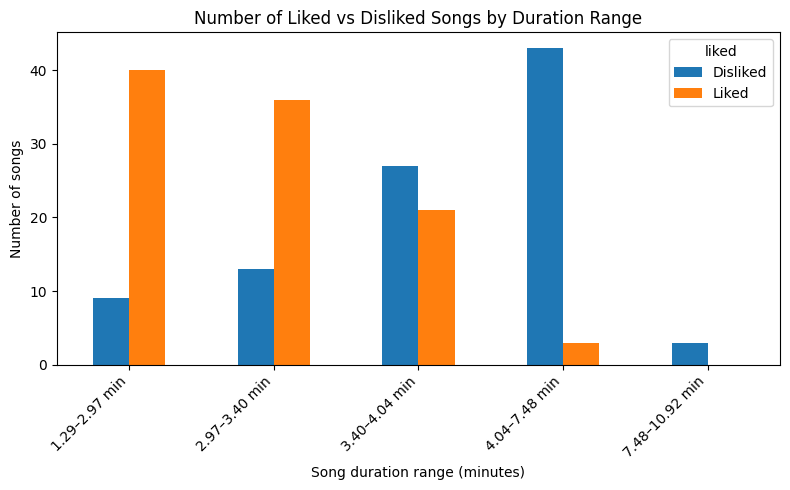

Multibar graph showing liked vs disliked songs by duration range with split category displayed.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("data.csv")

# 2. Convert duration to minutes
df["duration_min"] = df["duration_ms"] / 60000.0

# 3. Define duration ranges (quartiles or custom bins)

# Option A: Quartile-based bins (modified to split the last range)
quartiles = df["duration_min"].quantile([0.25, 0.5, 0.75])
# Splitting the last range (4.04-10.92 min) into two, using its midpoint
# The original last bin was from quartiles[0.75] to df["duration_min"].max()
# quartiles[0.75] is approximately 4.04
# df["duration_min"].max() is approximately 10.92
# Midpoint = (4.04 + 10.92) / 2 = 7.48

bins = [df["duration_min"].min() - 1e-6,
        quartiles[0.25],
        quartiles[0.5],
        quartiles[0.75],
        7.48, # New split point
        df["duration_min"].max() + 1e-6]
labels = [f"{bins[i]:.2f}–{bins[i+1]:.2f} min" for i in range(len(bins)-1)]

df["duration_range"] = pd.cut(df["duration_min"], bins=bins, labels=labels, include_lowest=True)

# 4. Count liked vs disliked per range
counts = (
    df.groupby(["duration_range", "liked"])
      .size()
      .unstack(fill_value=0)
      .rename(columns={0: "Disliked", 1: "Liked"})
)

# 5. Plot grouped (multi-bar) chart
plt.figure(figsize=(10, 6))
ax = counts.plot(kind="bar", figsize=(8, 5))
ax.set_xlabel("Song duration range (minutes)")
ax.set_ylabel("Number of songs")
ax.set_title("Number of Liked vs Disliked Songs by Duration Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Multibar graph showing liked vs disliked songs by duration range with split category displayed.")

Most liked range is 1.29-2.97 range while most disliked range is 7.48-10.92 minutes.

/tmp/ipython-input-4103674047.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  liked_songs_df['tempo_range'] = pd.cut(liked_songs_df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
/tmp/ipython-input-4103674047.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tempo_range_counts.index, y=tempo_range_counts.values, palette='coolwarm')


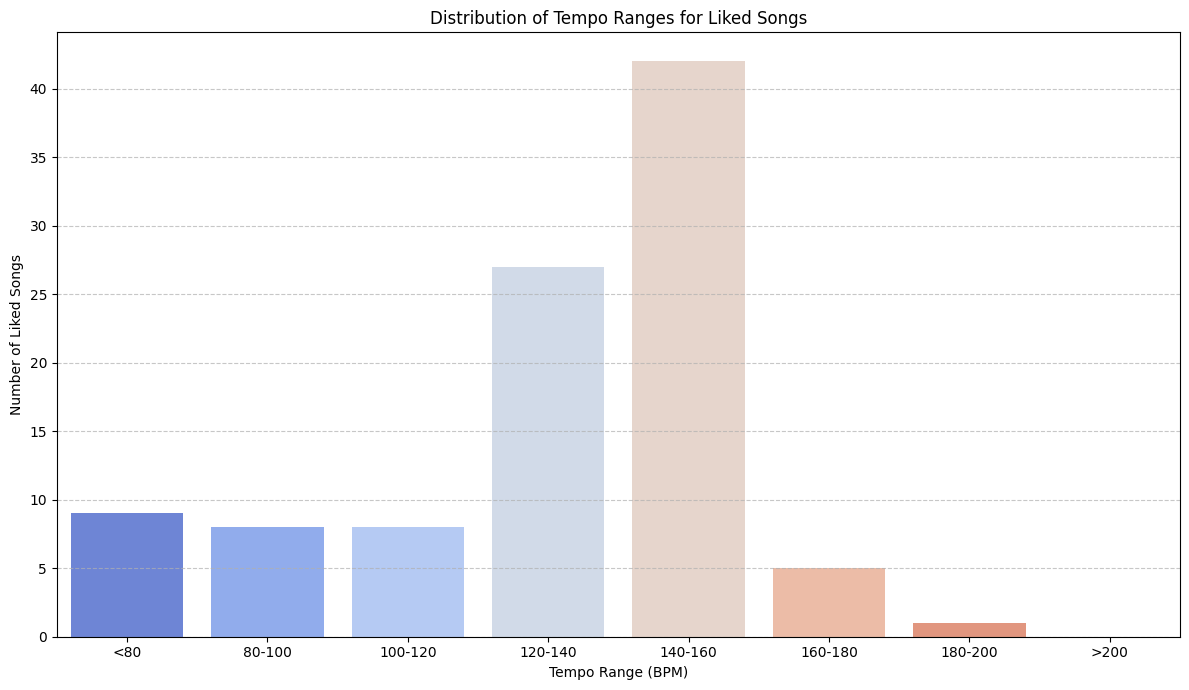

Bar graph showing top tempo ranges for liked songs displayed.


In [16]:
import numpy as np

# Filter for liked songs
liked_songs_df = df[df['liked'] == 1]

# Define tempo ranges (bins). You might adjust these based on the data's tempo distribution.
tempo_bins = [0, 80, 100, 120, 140, 160, 180, 200, np.inf] # Example bins
tempo_labels = ['<80', '80-100', '100-120', '120-140', '140-160', '160-180', '180-200', '>200']

# Categorize liked songs into tempo ranges
liked_songs_df['tempo_range'] = pd.cut(liked_songs_df['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)

# Count the number of liked songs in each tempo range
tempo_range_counts = liked_songs_df['tempo_range'].value_counts().sort_index()

plt.figure(figsize=(12, 7))
sns.barplot(x=tempo_range_counts.index, y=tempo_range_counts.values, palette='coolwarm')
plt.title('Distribution of Tempo Ranges for Liked Songs')
plt.xlabel('Tempo Range (BPM)')
plt.ylabel('Number of Liked Songs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Bar graph showing top tempo ranges for liked songs displayed.")

The plot indicates that there is a high preference for 140-160 bpm songs by a high amount with 120-140 bpm as the second highest preffered. Indicates that there isn't much diversity with regards to a preference of various tempos.

# Part E: Initial Insights and Direction

**Observation:** It is found that the most liked duration range is in the 1.29 - 2.97 minute range. From 3.40 minutes onwards the amount of dislikes are higher than the amount of likes. For songs greater than 4 minutes, the amount of likes significantly drops with there being no likes at all for songs within the 7.48-10 minute range.

**Hypothesis:** Listeners on Spotify tend to have lower attention spans

**Additional RQs**


*   Are certain age groups more likely to prefer a certain time length over another age group? Ex. Younger groups prefer shorter songs and older groups have more tolerance for longer songs?   
*   Does a user screentime patterns correspond to their dislike for a certain song length range?
* What tasks do spotify users perform while listening to music and how does that potentially relate to like/dislike patterns?



Github Link: https://github.com/sarkriti/CSCE-676-Semester-Project.git

```
On my honor, I declare the following resources:
1. Collaborators:
- None
2. Web Sources:
- None

3. AI Tools:
- Google Gemini:Helped implement code to create various EDA plots
- Perplexity: Helped summarize dataset structure and help identify dataset issues
- Perplexity: Helped implement code to create like/disliked songs time duration plot

4. Citations
* Kong, R., Anderson, T., Scotch, M., Heslop, D.
J., Khaokaew, Y., Xue, H., Xiong, L., MacIntyre, C. R., Salim, F. D., & Züfle, A. (2025). Simulated infectious diseases datasets with controlled data collection bias. In Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining (KDD ’25), Toronto, Canada. https://doi.org/10.1145/3711896.3737401
​
* Gu, C., Zaidi, Z. R., Luo, L., & Karunasekera, S. (2025). Latent Influence Network for discovering hidden directed influence links on social media. In Proceedings of the 19th International AAAI Conference on Web and Social Media (ICWSM 2025).
```